In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils.DataLoader import load_propeller_dict
import scienceplots

plt.style.use(['science', 'no-latex'])

In [2]:
prop_name, blade_dict = load_propeller_dict('../Data/10x7E')[0]

environment = Environment(
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    p_ref=2e-5,
)
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=100,
    device='cpu',
)

propeller = Propeller(
    geometry=blade_dict,
    environment=environment,
    simulation=simulation,
    use_cuda_timing=False,
)

In [3]:
rpm = 7000
advance_ratios = np.arange(0.0, 1.0, 0.1)

bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=rpm,
    J=advance_ratios,
)

performance = bemt.performance.reset_index()
diameter = 2.0 * blade_dict['tip_radius']
performance['J'] = performance['v_inf'] / (
    performance['rpm'] / 60.0 * diameter
)
performance['efficiency'] = np.divide(
    performance['J'] * performance['thrust_coefficient'],
    2.0 * np.pi * performance['torque_coefficient'],
    out=np.zeros(len(performance)),
    where=performance['torque_coefficient'].to_numpy() > 0.0,
)

print(f'Propeller: {prop_name}')
performance

Propeller: 10x7E


,rpm,v_inf,thrust,torque,thrust_coefficient,torque_coefficient,figure_of_merit,J,efficiency
0,7000.0,0.000000,8.059078,0.134538,0.116124,0.007632,0.658408,0.0,0.000000
1,7000.0,2.963333,8.243566,0.149353,0.118782,0.008473,0.613580,0.1,0.223129
2,7000.0,5.926667,7.748531,0.157118,0.111649,0.008913,0.531515,0.2,0.398730
3,7000.0,8.890000,6.983785,0.158321,0.100630,0.008981,0.451345,0.3,0.534967
4,7000.0,11.853333,5.898238,0.149860,0.084988,0.008501,0.370091,0.4,0.636429
5,7000.0,14.816667,4.559620,0.130899,0.065700,0.007426,0.287984,0.5,0.704071
6,7000.0,17.780000,3.062221,0.101545,0.044124,0.005761,0.204318,0.6,0.731446
7,7000.0,20.743333,1.451856,0.061815,0.020920,0.003507,0.109573,0.7,0.664632
8,7000.0,23.706667,-0.345650,0.011119,-0.004980,0.000631,NaN,0.8,-1.005321
9,7000.0,26.670000,-2.236312,-0.043428,-0.032223,-0.002464,NaN,0.9,0.000000


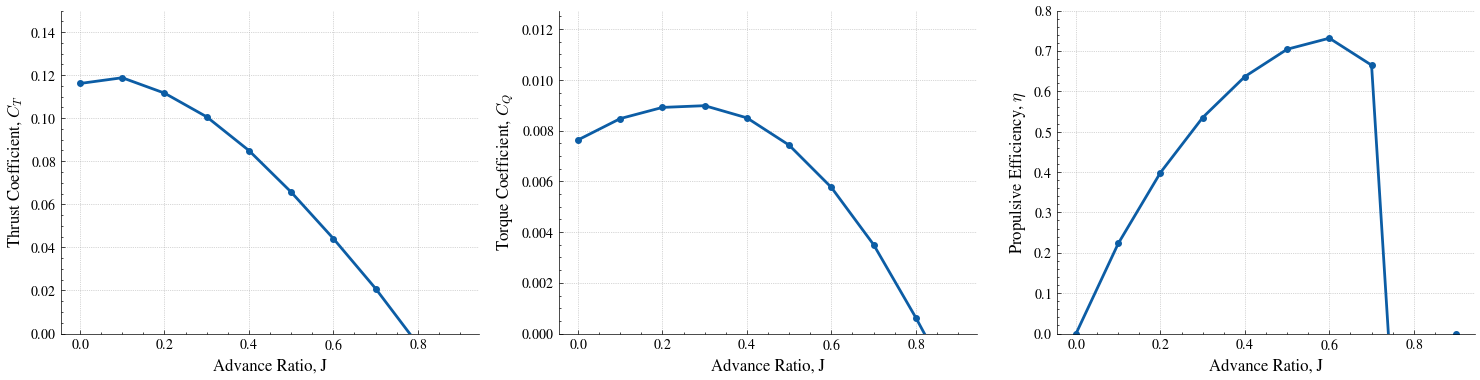

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(performance['J'], performance['thrust_coefficient'], 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Advance Ratio, J', fontsize=12)
axes[0].set_ylabel('Thrust Coefficient, $C_T$', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both')
axes[0].set_ylim(0, 0.15)

axes[1].plot(performance['J'], performance['torque_coefficient'], 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Advance Ratio, J', fontsize=12)
axes[1].set_ylabel('Torque Coefficient, $C_Q$', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both')
axes[1].set_ylim(0, 0.08 / 2 / np.pi)

axes[2].plot(performance['J'], performance['efficiency'], 'o-', linewidth=2, markersize=4)
axes[2].set_xlabel('Advance Ratio, J', fontsize=12)
axes[2].set_ylabel('Propulsive Efficiency, $\\eta$', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both')
axes[2].set_ylim(0, 0.8)

plt.tight_layout()
figure_path = Path('../Figures/Validation/bemt_performance.pdf')
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=200)
plt.show()